# Simple Linear Regression (Python)

This notebook reads `regression_data.csv`, plots the data, fits a simple linear regression of **Salary** on **YearsExperience**, overlays the fitted line, and evaluates the model.

**How to run:**

1. Create the conda environment from the project root:
   ```bash
   conda env create -f environment.yml
   conda activate regression-analysis
   ```
2. Open this notebook in Jupyter / VS Code / Cursor and run all cells top to bottom.
3. Keep `regression_data.csv` in the same folder as this notebook.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


pandas: 3.0.3
numpy: 2.5.1


In [2]:
# Resolve the CSV next to this notebook / in the working directory
candidates = [
    Path.cwd() / "regression_data.csv",
    Path("regression_data.csv"),
]

# When running as a notebook, also try the notebook's directory
try:
    candidates.insert(0, Path(__file__).resolve().parent / "regression_data.csv")
except NameError:
    pass

data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Could not find regression_data.csv. "
        "Place it in the same folder as this notebook and set the working directory to that folder."
    )

print(f"Using data file: {data_path.resolve()}")

Using data file: /Users/lizzieadams/regression-analysis/regression_data.csv


## 1. Load and inspect the data

In [3]:
df = pd.read_csv(data_path)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}\n")
df

Shape: 10 rows x 2 columns
Columns: ['YearsExperience', 'Salary']



,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.7,57189.0
9,4.0,63218.0


In [4]:
print(df.describe())
print()
df.info()

       YearsExperience        Salary
count        10.000000     10.000000
mean          2.490000  49833.900000
std           1.018114   9519.789814
min           1.100000  37731.000000
25%           1.625000  40799.500000
50%           2.550000  50325.000000
75%           3.150000  57052.250000
max           4.000000  63218.000000

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  10 non-null     float64
 1   Salary           10 non-null     float64
dtypes: float64(2)
memory usage: 292.0 bytes


## 2. Scatter plot

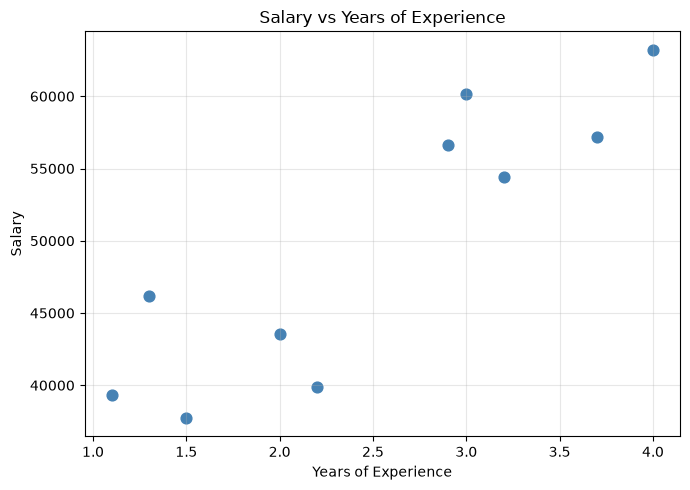

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["YearsExperience"], df["Salary"], color="steelblue", s=60)
ax.set_title("Salary vs Years of Experience")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Salary")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Fit a simple linear regression model

Model: `Salary = intercept + slope * YearsExperience + error`

In [6]:
X = df[["YearsExperience"]].to_numpy()
y = df["Salary"].to_numpy()

model = LinearRegression()
model.fit(X, y)

intercept = float(model.intercept_)
slope = float(model.coef_[0])

print(f"Fitted model: Salary = {intercept:.2f} + {slope:.2f} * YearsExperience")
print(f"Intercept: {intercept:.4f}")
print(f"Slope:     {slope:.4f}")

Fitted model: Salary = 29203.52 + 8285.29 * YearsExperience
Intercept: 29203.5227
Slope:     8285.2921


## 4. Overlay the regression line

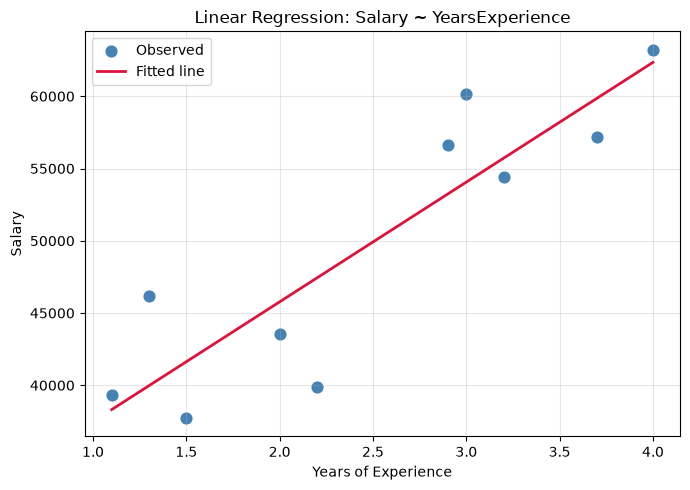

In [7]:
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["YearsExperience"], df["Salary"], color="steelblue", s=60, label="Observed")
ax.plot(x_line, y_line, color="#DC143C", linewidth=2, label="Fitted line")
ax.set_title("Linear Regression: Salary ~ YearsExperience")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Salary")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Evaluate the model

In [8]:
y_pred = model.predict(X)
residuals = y - y_pred

n = len(y)
p = 1  # number of predictors
r2 = r2_score(y, y_pred)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = float(np.sqrt(mse))

print("Model evaluation")
print("-" * 40)
print(f"R-squared:           {r2:.4f}")
print(f"Adjusted R-squared:  {adj_r2:.4f}")
print(f"MAE:                 {mae:.2f}")
print(f"MSE:                 {mse:.2f}")
print(f"RMSE:                {rmse:.2f}")
print(f"Residual mean:       {residuals.mean():.4f}")
print(f"Residual std. dev.:  {residuals.std(ddof=1):.2f}")

Model evaluation
----------------------------------------
R-squared:           0.7852
Adjusted R-squared:  0.7583
MAE:                 3526.26
MSE:                 17523844.08
RMSE:                4186.15
Residual mean:       0.0000
Residual std. dev.:  4412.59


In [9]:
results = pd.DataFrame(
    {
        "YearsExperience": df["YearsExperience"],
        "Salary": y,
        "Predicted": y_pred,
        "Residual": residuals,
    }
)
results

,YearsExperience,Salary,Predicted,Residual
0,1.1,39343.0,38317.343981,1025.656019
1,1.3,46205.0,39974.402401,6230.597599
2,1.5,37731.0,41631.460821,-3900.460821
3,2.0,43525.0,45774.106871,-2249.106871
4,2.2,39891.0,47431.165291,-7540.165291
5,2.9,56642.0,53230.869761,3411.130239
6,3.0,60150.0,54059.398971,6090.601029
7,3.2,54445.0,55716.457391,-1271.457391
8,3.7,57189.0,59859.103441,-2670.103441
9,4.0,63218.0,62344.691071,873.308929


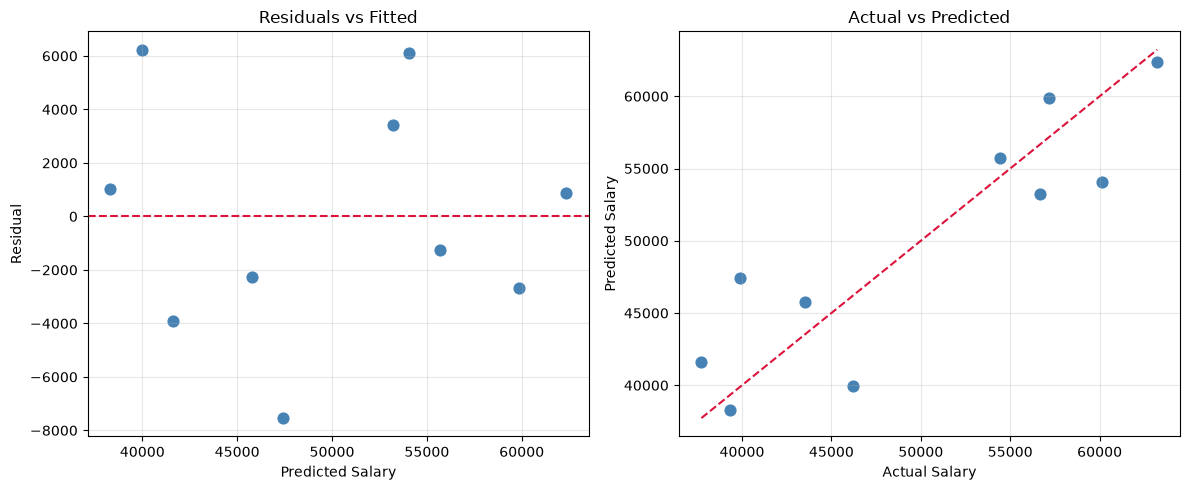

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred, residuals, color="steelblue", s=60)
axes[0].axhline(0, color="#DC143C", linestyle="--")
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y, y_pred, color="steelblue", s=60)
lims = [
    min(y.min(), y_pred.min()),
    max(y.max(), y_pred.max()),
]
axes[1].plot(lims, lims, color="#DC143C", linestyle="--")
axes[1].set_title("Actual vs Predicted")
axes[1].set_xlabel("Actual Salary")
axes[1].set_ylabel("Predicted Salary")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

- The scatter plot shows the relationship between years of experience and salary.
- A simple linear regression was fit with scikit-learn `LinearRegression`.
- The regression line was overlaid on the scatter plot.
- Model quality was assessed with R², adjusted R², MAE, MSE/RMSE, and residual plots.